# 🧠 CNN-LSTM Projection Notebook
### Warranty Claim Forecasting — Dual CNN-LSTM Architecture (Baseline & CM)

**Purpose:** Standalone notebook running two independent CNN-LSTM models:
one for the baseline scenario and a separate one trained under the
countermeasure (CM) production trajectory with warranty-expiry physics.

**Model Architecture:**
```
Input (W, nf)
  → Conv1D(32 filters, kernel=3, same-padding) → ReLU
  → Conv1D(64 filters, kernel=3, same-padding) → ReLU
  → LSTM(64 units) — last hidden state
  → Dense(64 → H)
```
- **Conv1D layers** extract local temporal patterns (3-month windows)
- **LSTM layer** captures long-range sequential dependencies
- **Exogenous features** (Production_Vol, Vehicle_Age, Claim_Weight) are part of the input tensor

**Modes:**
- **Baseline** — CNN-LSTM trained on historical data; predicts future claims without CM.
- **Countermeasure-Adjusted** — Separate CNN-LSTM + warranty-expiry physics blend.

---

### Workflow
1. `Cell 1`  — Imports and self-contained module definitions
2. `Cell 2`  — **User Input** — CSV paths, part name, CM date, forecast settings
3. `Cell 3`  — Data loading and preprocessing
4. `Cell 4`  — **Feature Engineering** — builds feature matrix
5. `Cell 5`  — **Baseline CNN-LSTM** — standard training & baseline forecast
6. `Cell 6`  — **CM CNN-LSTM** — separate model + warranty-expiry physics guarantee
7. `Cell 7`  — Side-by-side visualisation
8. `Cell 8`  — Numerical results and CSV export
9. `Cell 9`  — PowerPoint export
10. `Cell 10` — Edge-case testing utilities

> **Dependencies:** `numpy pandas scikit-learn matplotlib tqdm python-pptx`
> Install with: `pip install numpy pandas scikit-learn matplotlib tqdm python-pptx`


In [1]:
# ============================================================
# CELL 1 — Imports & CNN-LSTM model definitions
# Self-contained: no external forecasting package required.
# ============================================================

from __future__ import annotations
import io, os, sys, warnings
from datetime import datetime
from pathlib import Path
from typing import Optional
import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from sklearn.preprocessing import MinMaxScaler
warnings.filterwarnings("ignore")

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable=None, **kwargs):
        return iterable if iterable is not None else range(kwargs.get("total", 0))

print("✅ Core imports OK")

# ── Dark theme ────────────────────────────────────────────────────────────────
plt.style.use("dark_background")
matplotlib.rcParams.update({
    "figure.facecolor": "#0F1117", "axes.facecolor": "#1A1D2E",
    "axes.edgecolor": "#2E3250", "axes.labelcolor": "#C8CFFF",
    "axes.grid": True, "grid.color": "#2E3250", "grid.linestyle": "--",
    "grid.alpha": 0.5, "xtick.color": "#8892B0", "ytick.color": "#8892B0",
    "text.color": "#CCD6F6", "font.family": "DejaVu Sans", "font.size": 10,
    "legend.framealpha": 0.85, "legend.facecolor": "#1A1D2E",
    "legend.edgecolor": "#2E3250",
})

C_BASELINE = "#6C63FF"; C_CM = "#43D9AD"; C_HIST = "#FFBB35"
C_REDUCTION = "#FF6584"; C_CUM = "#4FC3F7"; C_CM_LINE = "#FF8A65"
C_PROD = "#CE93D8"

WARRANTY_MONTHS = 36; FORECAST_HORIZON = 12; LOOKBACK_WINDOW = 12
RANDOM_SEED = 42; np.random.seed(RANDOM_SEED)
print("✅ Style & constants ready")

# ─────────────────────────────────────────────────────────────────────────────
# BASE UTILITIES
# ─────────────────────────────────────────────────────────────────────────────

def relu(x): return np.maximum(0, x)

def sigmoid(x): return 1.0 / (1.0 + np.exp(-np.clip(x, -50, 50)))

def apply_dropout(x, rate, training):
    if (not training) or rate <= 0.0: return x
    keep = 1.0 - float(rate)
    mask = (np.random.rand(*x.shape) < keep).astype(x.dtype)
    return x * mask / keep


class EarlyStopTracker:
    def __init__(self, patience=5, min_delta=1e-6):
        self.patience = max(1, int(patience)); self.min_delta = float(min_delta)
        self.best_loss = np.inf; self.bad_epochs = 0; self.best_state = None
    def step(self, loss, state=None):
        if loss < self.best_loss - self.min_delta:
            self.best_loss = float(loss); self.bad_epochs = 0
            if state is not None:
                self.best_state = {k: np.copy(v) for k, v in state.items()}
            return False
        self.bad_epochs += 1
        return self.bad_epochs >= self.patience


class AdamOptimizer:
    def __init__(self, lr=1e-3, b1=0.9, b2=0.999, eps=1e-8):
        self.lr, self.b1, self.b2, self.eps = lr, b1, b2, eps
        self.t = 0; self.m = {}; self.v = {}
    def update(self, key, param, grad):
        if key not in self.m:
            self.m[key] = np.zeros_like(param); self.v[key] = np.zeros_like(param)
        self.t += 1
        self.m[key] = self.b1 * self.m[key] + (1 - self.b1) * grad
        self.v[key] = self.b2 * self.v[key] + (1 - self.b2) * grad ** 2
        mh = self.m[key] / (1 - self.b1 ** self.t)
        vh = self.v[key] / (1 - self.b2 ** self.t)
        return param - self.lr * mh / (np.sqrt(vh) + self.eps)


# ─────────────────────────────────────────────────────────────────────────────
# CNN-LSTM FORECASTER
# ─────────────────────────────────────────────────────────────────────────────

class CNNLSTMForecaster:
    """
    Pure-NumPy CNN-LSTM warranty claim forecaster.

    Architecture:
      Input (W, nf)
      → Conv1D(n_filters_1, k=3, same-padding) → ReLU
      → Conv1D(n_filters_2, k=3, same-padding) → ReLU   [dropout]
      → LSTM(lstm_units)   — processes the conv feature sequence
      → last hidden state  → Dense(H)

    Conv1D uses same-length (edge) padding so output length = W always.
    LSTM uses standard gated equations; returns the final hidden state.
    Training uses Adam + numerical-gradient updates (finite differences).
    """

    def __init__(self, lookback=12, n_features=13, horizon=12,
                 n_filters_1=32, n_filters_2=64, lstm_units=64,
                 lr=3e-3, epochs=80, seed=42, dropout=0.2, early_patience=7):
        np.random.seed(seed)
        self.W = lookback; self.F = n_features; self.H = horizon
        self.nf1 = n_filters_1; self.nf2 = n_filters_2; self.lu = lstm_units
        self.lr = lr; self.epochs = epochs
        self.dropout = float(dropout); self.early_patience = int(early_patience)
        self._init_weights()

    def _init_weights(self):
        k = 3
        # Conv1: (nf1, k, F)  →  same-pad output (W, nf1)
        self.Wc1 = np.random.randn(self.nf1, k, self.F)  * 0.05
        self.bc1 = np.zeros(self.nf1)
        # Conv2: (nf2, k, nf1) →  same-pad output (W, nf2)
        self.Wc2 = np.random.randn(self.nf2, k, self.nf1) * 0.05
        self.bc2 = np.zeros(self.nf2)
        # LSTM gates — combined input (nf2 + lu) → lu
        inp = self.nf2 + self.lu
        self.Wf = np.random.randn(inp, self.lu) * 0.05   # forget
        self.Wi = np.random.randn(inp, self.lu) * 0.05   # input
        self.Wo = np.random.randn(inp, self.lu) * 0.05   # output
        self.Wg = np.random.randn(inp, self.lu) * 0.05   # cell
        self.bf = np.ones(self.lu)    # initialise forget bias to 1
        self.bi = np.zeros(self.lu)
        self.bo = np.zeros(self.lu)
        self.bg = np.zeros(self.lu)
        # Dense: lu → H
        self.Wd = np.random.randn(self.lu, self.H) * 0.1
        self.bd = np.zeros(self.H)

    # ── Conv1D with same-length (edge) padding ────────────────────────────────
    def _conv1d(self, x, W, b):
        """x: (T, F_in)  W: (F_out, k, F_in) → (T, F_out)  [same padding]"""
        T, F_in = x.shape; k = W.shape[1]; pad = (k - 1) // 2
        if pad > 0:
            x = np.pad(x, ((pad, pad), (0, 0)), mode="edge")
        out_T = x.shape[0] - k + 1
        out = np.zeros((out_T, W.shape[0]))
        for t in range(out_T):
            out[t] = np.tensordot(W, x[t:t+k], axes=([1, 2], [0, 1])) + b
        return out  # (T, F_out)

    # ── LSTM: process sequence, return last hidden state ──────────────────────
    def _lstm_last(self, x):
        """x: (T, nf2) → last hidden state (lu,)"""
        h = np.zeros(self.lu); c = np.zeros(self.lu)
        for t in range(x.shape[0]):
            xh = np.concatenate([x[t], h])
            fg = sigmoid(xh @ self.Wf + self.bf)
            ig = sigmoid(xh @ self.Wi + self.bi)
            og = sigmoid(xh @ self.Wo + self.bo)
            gg = np.tanh(xh  @ self.Wg + self.bg)
            c  = fg * c + ig * gg
            h  = og * np.tanh(c)
        return h

    # ── Forward pass ──────────────────────────────────────────────────────────
    def _forward(self, x, training=False):
        """x: (W, nf) → prediction (H,)"""
        if training and self.dropout > 0:
            x = apply_dropout(x, self.dropout, training)
        c1 = relu(self._conv1d(x,  self.Wc1, self.bc1))   # (W, nf1)
        c2 = relu(self._conv1d(c1, self.Wc2, self.bc2))   # (W, nf2)
        if training and self.dropout > 0:
            c2 = apply_dropout(c2, self.dropout, training)
        h  = self._lstm_last(c2)                           # (lu,)
        if training and self.dropout > 0:
            h = h * (np.random.rand(*h.shape) > self.dropout)
        return h @ self.Wd + self.bd                       # (H,)

    def _param_names(self):
        return ["Wc1", "bc1", "Wc2", "bc2",
                "Wf", "Wi", "Wo", "Wg", "bf", "bi", "bo", "bg", "Wd", "bd"]

    def _snapshot(self):
        return {k: np.copy(getattr(self, k)) for k in self._param_names()}

    def _restore(self, state):
        for k, v in state.items(): setattr(self, k, np.copy(v))

    # ── Training ──────────────────────────────────────────────────────────────
    def fit(self, X, y):
        opt = AdamOptimizer(self.lr); N = X.shape[0]; eps = 1e-3
        stopper = EarlyStopTracker(patience=self.early_patience)
        bar = tqdm(range(self.epochs), desc="CNN-LSTM epochs", unit="ep", leave=True)
        for _ in bar:
            epoch_loss = 0.0
            for i in np.random.permutation(N):
                xi, yi = X[i], y[i]
                pred = self._forward(xi, training=True)
                epoch_loss += float(np.mean((pred - yi) ** 2))
                dL = 2 * (pred - yi) / self.H
                # Analytical gradient for Dense layer
                c1 = relu(self._conv1d(xi, self.Wc1, self.bc1))
                c2 = relu(self._conv1d(c1, self.Wc2, self.bc2))
                h  = self._lstm_last(c2)
                self.Wd = opt.update("Wd", self.Wd, np.outer(h, dL))
                self.bd = opt.update("bd", self.bd, dL)
                # Numerical gradients for conv + LSTM weights (subsample)
                for name in ["Wc1", "Wc2", "Wf", "Wi", "Wo", "Wg"]:
                    W_ = getattr(self, name)
                    grad = np.zeros_like(W_)
                    idxs = np.random.choice(W_.size, min(W_.size, 30), replace=False)
                    flat = W_.ravel()
                    for j in idxs:
                        orig = flat[j]
                        flat[j] = orig + eps
                        setattr(self, name, flat.reshape(W_.shape))
                        pp = self._forward(xi)
                        flat[j] = orig - eps
                        setattr(self, name, flat.reshape(W_.shape))
                        pm = self._forward(xi)
                        flat[j] = orig
                        setattr(self, name, flat.reshape(W_.shape))
                        grad.ravel()[j] = (np.mean((pp-yi)**2) - np.mean((pm-yi)**2)) / (2*eps)
                    setattr(self, name, opt.update(name, getattr(self, name), grad))
            mean_loss = epoch_loss / max(N, 1)
            if hasattr(bar, "set_postfix"):
                bar.set_postfix(loss=f"{mean_loss:.4f}")
            if stopper.step(mean_loss, self._snapshot()):
                if stopper.best_state: self._restore(stopper.best_state)
                break
        else:
            if stopper.best_state: self._restore(stopper.best_state)
        return self

    def predict(self, X):
        return np.array([self._forward(xi) for xi in X])


# ─────────────────────────────────────────────────────────────────────────────
# FEATURE ENGINEERING  (identical to transformer_projection.ipynb)
# ─────────────────────────────────────────────────────────────────────────────

UNI_FEATURE_COLS = [
    "Lag_1", "Lag_2", "Lag_3", "Lag_12",
    "Month", "Quarter", "Year",
    "Trend_Index", "Seasonality_Index",
    "Production_Vol", "Vehicle_Age", "Claim_Weight",
]


def build_univariate_features(claims, periods, production=None):
    s = pd.Series(np.asarray(claims, dtype=float).ravel()); n = len(s)
    months   = np.array([int(pd.Period(p, freq="M").month)   for p in periods], dtype=float)
    years    = np.array([int(pd.Period(p, freq="M").year)    for p in periods], dtype=float)
    quarters = np.array([int(pd.Period(p, freq="M").quarter) for p in periods], dtype=float)
    df = pd.DataFrame({
        "claims": s.values, "Lag_1": s.shift(1), "Lag_2": s.shift(2),
        "Lag_3": s.shift(3), "Lag_12": s.shift(12),
        "Month": months, "Quarter": quarters, "Year": years,
        "Trend_Index": np.arange(n, dtype=float),
    })
    df["Seasonality_Index"] = (s.groupby(months).transform("mean") / (float(s.mean()) + 1e-9)).values
    prod_arr = np.asarray(production, dtype=float).ravel() if production is not None else np.full(n, 25_000.0)
    prod_arr = prod_arr[:n] if len(prod_arr) >= n else np.pad(prod_arr, (0, n - len(prod_arr)), mode="edge")
    df["Production_Vol"] = prod_arr
    df["Vehicle_Age"]    = np.minimum(np.arange(n, dtype=float), float(WARRANTY_MONTHS))
    df["Claim_Weight"]   = (s.values / (float(s.max()) + 1e-9)).clip(0, 1)
    return df.bfill().ffill().fillna(0.0)


def build_window_dataset(series_vals, exog, lookback, horizon):
    N = len(series_vals) - lookback - horizon + 1
    if N <= 0: return None, None
    X_list, y_list = [], []
    for i in range(N):
        X_list.append(np.concatenate([series_vals[i:i+lookback, None], exog[i:i+lookback]], axis=1))
        y_list.append(series_vals[i+lookback:i+lookback+horizon])
    return np.array(X_list), np.array(y_list)


def load_monthly_claims_csv(path):
    path_l = str(path).lower()
    df = pd.read_excel(path) if path_l.endswith((".xlsx", ".xls")) else pd.read_csv(path)
    if df.empty: raise ValueError("Claims file is empty.")
    col_map = {str(c).lower().strip(): c for c in df.columns}
    rename = {}
    for canon, aliases in {
        "Part Name": ["part name","part","part_name","partname"],
        "Month":     ["month","period","date","claim_month","year_month"],
        "Claims":    ["claims","claim_count","claim","count","volume","part_failure"],
    }.items():
        if canon in df.columns: continue
        for a in aliases:
            if a in col_map: rename[col_map[a]] = canon; break
    if rename: df = df.rename(columns=rename)
    missing = [c for c in ("Part Name","Month","Claims") if c not in df.columns]
    if missing: raise ValueError(f"CSV missing: {missing}")
    out = df[["Part Name","Month","Claims"]].copy()
    out["Part Name"] = out["Part Name"].astype(str).str.strip()
    out["Month"]     = out["Month"].astype(str).str.strip()
    out["Claims"]    = pd.to_numeric(out["Claims"], errors="coerce").fillna(0.0)
    return out[out["Part Name"].ne("") & out["Part Name"].ne("nan")].reset_index(drop=True)


def load_production_csv(path):
    path_l = str(path).lower()
    df = pd.read_excel(path) if path_l.endswith((".xlsx", ".xls")) else pd.read_csv(path)
    if df.empty: raise ValueError("Production file is empty.")
    col_map = {str(c).lower().strip(): c for c in df.columns}
    rename = {}
    for canon, aliases in {
        "Month": ["month","period","wty_month"],
        "Production": ["production","prod","volume","units"],
    }.items():
        if canon in df.columns: continue
        for a in aliases:
            if a in col_map: rename[col_map[a]] = canon; break
    if rename: df = df.rename(columns=rename)
    out = df[["Month","Production"]].copy()
    out["Month"]      = out["Month"].astype(str).str.strip()
    out["Production"] = pd.to_numeric(out["Production"], errors="coerce").fillna(0.0)
    return out.reset_index(drop=True)


def monthly_from_claims_sheet(sheet, part):
    sub = sheet[sheet["Part Name"].astype(str) == str(part)].copy()
    if sub.empty: return pd.DataFrame(columns=["period","claim_count"])
    parsed = []
    for m in sub["Month"]:
        try: parsed.append(pd.Period(pd.to_datetime(str(m)), freq="M"))
        except Exception:
            try: parsed.append(pd.Period(str(m), freq="M"))
            except: parsed.append(None)
    sub["period"] = parsed
    sub = sub[sub["period"].notna()]
    if sub.empty: return pd.DataFrame(columns=["period","claim_count"])
    agg = sub.groupby("period", as_index=False)["Claims"].sum().rename(columns={"Claims":"claim_count"}).sort_values("period")
    full = pd.period_range(agg["period"].min(), agg["period"].max(), freq="M")
    monthly = agg.set_index("period").reindex(full).reset_index()
    monthly.columns = ["period","claim_count"]
    monthly["claim_count"] = monthly["claim_count"].fillna(0.0)
    return monthly


def build_production_series(prod_df, periods, default_vol=25_000.0):
    if prod_df is None or prod_df.empty: return np.full(len(periods), default_vol)
    p2p = {}
    for _, row in prod_df.iterrows():
        try: p2p[str(pd.Period(row["Month"], freq="M"))] = float(row["Production"])
        except: pass
    return np.array([p2p.get(str(pd.Period(p, freq="M")), default_vol) for p in periods], dtype=float)


# ─────────────────────────────────────────────────────────────────────────────
# COUNTERMEASURE ENGINE  (identical to transformer_projection.ipynb)
# ─────────────────────────────────────────────────────────────────────────────

def identify_peak_fcok_months(raw, part, top_n=3, pct_threshold=0.90):
    def _apply(by_fcok, thr):
        total = float(by_fcok["claim_count"].sum())
        if total <= 0: return by_fcok.head(1)
        cum = by_fcok["claim_count"].cumsum()
        mask = cum >= thr * total
        return by_fcok.head(max(int(mask.idxmax()) + 1, 1)) if mask.any() else by_fcok
    if "FCOK_MONTH" in raw.columns:
        sub = raw[raw["Part Name"] == part].dropna(subset=["FCOK_MONTH"])
        if not sub.empty:
            by_fcok = (sub.groupby("FCOK_MONTH").size().reset_index(name="claim_count")
                       .rename(columns={"FCOK_MONTH":"fcok_month"})
                       .sort_values("claim_count", ascending=False).reset_index(drop=True))
            by_fcok["rank"] = by_fcok.index + 1
            return _apply(by_fcok, pct_threshold)
    if "Part Name" in raw.columns and "Month" in raw.columns and "Claims" in raw.columns:
        sub = raw[raw["Part Name"] == part].copy()
        if not sub.empty:
            by_fcok = (sub.groupby("Month", as_index=False)["Claims"].sum()
                       .rename(columns={"Month":"fcok_month","Claims":"claim_count"})
                       .sort_values("claim_count", ascending=False).reset_index(drop=True))
            by_fcok["rank"] = by_fcok.index + 1
            return _apply(by_fcok, pct_threshold)
    return pd.DataFrame(columns=["fcok_month","claim_count","rank"])


def compute_adjusted_baseline_production(raw, part, production_series, monthly_periods, top_n=3):
    peak_df = identify_peak_fcok_months(raw, part, top_n=top_n)
    prod_arr = np.asarray(production_series, dtype=float)
    if peak_df.empty:
        avg_prod = float(np.nanmean(prod_arr)) if len(prod_arr) else 25_000.0
        return {"avg_peak_prod": avg_prod, "avg_peak_claims": 0.0,
                "adj_prod": avg_prod, "peak_fcok_df": peak_df}
    period_to_prod = {str(p): float(prod_arr[i]) for i, p in enumerate(monthly_periods) if i < len(prod_arr)}
    peak_prod_vals = [period_to_prod.get(str(fm), np.nan) for fm in peak_df["fcok_month"]]
    peak_prod_vals = [v for v in peak_prod_vals if np.isfinite(v) and v > 0]
    avg_peak_prod  = float(np.mean(peak_prod_vals)) if peak_prod_vals else float(np.nanmean(prod_arr)) if np.any(np.isfinite(prod_arr)) else 25_000.0
    avg_peak_claims = float(peak_df["claim_count"].mean())
    return {"avg_peak_prod": avg_peak_prod, "avg_peak_claims": avg_peak_claims,
            "adj_prod": max(avg_peak_prod - avg_peak_claims, 1.0), "peak_fcok_df": peak_df}


def build_cm_adjusted_production(adj_prod_start, avg_peak_claims, n_months, warranty_months=WARRANTY_MONTHS):
    result = np.array([adj_prod_start - t * avg_peak_claims if t < warranty_months else adj_prod_start
                       for t in range(n_months)])
    return np.clip(result, 1.0, None)


def compare_forecasts(baseline, cm_forecast, future_periods, cost_per_claim=None):
    baseline = np.asarray(baseline, dtype=float).ravel()
    cm_fc    = np.asarray(cm_forecast, dtype=float).ravel()
    H        = min(len(baseline), len(cm_fc))
    baseline, cm_fc = baseline[:H], cm_fc[:H]
    monthly_red = np.clip(baseline - cm_fc, 0.0, None)
    cum_red     = np.cumsum(monthly_red)
    pct_red     = np.where(baseline > 0, monthly_red / baseline * 100.0, 0.0)
    total_base  = float(baseline.sum()); total_cm = float(cm_fc.sum())
    total_red   = float(monthly_red.sum()); total_pct = float(total_red / (total_base + 1e-9) * 100.0)
    cost_sav = total_cost_sav = None
    if cost_per_claim is not None and np.isfinite(cost_per_claim) and cost_per_claim > 0:
        cost_sav = monthly_red * float(cost_per_claim); total_cost_sav = float(cost_sav.sum())
    periods_str = [str(p) for p in list(future_periods)[:H]]
    comp_df = pd.DataFrame({
        "Month": periods_str, "Baseline_Claims": baseline, "CM_Claims": cm_fc,
        "Monthly_Reduction": monthly_red, "Cumulative_Reduction": cum_red,
        "Reduction_%": pct_red,
    })
    if cost_sav is not None: comp_df["Cost_Savings"] = cost_sav
    return {"baseline": baseline, "cm_forecast": cm_fc, "monthly_reduction": monthly_red,
            "cumulative_reduction": cum_red, "pct_reduction": pct_red, "cost_savings": cost_sav,
            "total_baseline_claims": total_base, "total_cm_claims": total_cm,
            "total_reduction": total_red, "total_pct_reduction": total_pct,
            "total_cost_savings": total_cost_sav, "cost_per_claim": cost_per_claim,
            "comparison_df": comp_df}


print("✅ All module definitions loaded")
print("   ↳ CNNLSTMForecaster | CM engine | preprocessing | data loaders")
print()
print("━" * 60)
print("  Ready — proceed to Cell 2 to configure inputs")
print("━" * 60)


✅ Core imports OK
✅ Style & constants ready
✅ All module definitions loaded
   ↳ CNNLSTMForecaster | CM engine | preprocessing | data loaders

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Ready — proceed to Cell 2 to configure inputs
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [2]:
# ============================================================
# CELL 2 — ✏️ USER INPUT SECTION  (edit values here)
# ============================================================

CLAIMS_CSV_PATH     = None   # str | None  (None = synthetic demo)
PRODUCTION_CSV_PATH = None   # str | None  (optional)
PART_NAME           = None   # str | None  (None = auto-select first part)

COUNTERMEASURE_TAKEN = True
COUNTERMEASURE_DATE  = "2023-06"   # YYYY-MM

HORIZON          = 12
LOOKBACK         = 12
MODEL_EPOCHS     = 60   # max training epochs (CNN-LSTM)

COST_PER_CLAIM     = 850.0
DEFAULT_PRODUCTION = 25_000
OUTPUT_DIR_NB      = "."
EXPORT_PPT         = True

print("━" * 60)
print("  CNN-LSTM INPUT CONFIGURATION")
print("━" * 60)
print(f"  Claims CSV      : {CLAIMS_CSV_PATH or '(synthetic demo)'}")
print(f"  CM Taken        : {COUNTERMEASURE_TAKEN}")
if COUNTERMEASURE_TAKEN:
    print(f"  CM Date         : {COUNTERMEASURE_DATE}")
print(f"  Horizon         : {HORIZON} months | Lookback: {LOOKBACK} months")
print(f"  Epochs          : {MODEL_EPOCHS}")
print("━" * 60)

if COUNTERMEASURE_TAKEN:
    try: pd.Period(COUNTERMEASURE_DATE, freq="M"); print(f"  ✅ CM date valid")
    except: raise ValueError(f"Invalid COUNTERMEASURE_DATE: {COUNTERMEASURE_DATE}")

os.makedirs(OUTPUT_DIR_NB, exist_ok=True)
print(f"  ✅ Output dir: {os.path.abspath(OUTPUT_DIR_NB)}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  CNN-LSTM INPUT CONFIGURATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Claims CSV      : (synthetic demo)
  CM Taken        : True
  CM Date         : 2023-06
  Horizon         : 12 months | Lookback: 12 months
  Epochs          : 60
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✅ CM date valid
  ✅ Output dir: d:\forecasting_cursor_copy2


In [3]:
# ============================================================
# CELL 3 — Data loading & preprocessing
# ============================================================

def _generate_synthetic_claims(n_months=48, seed=42, n_parts=3):
    np.random.seed(seed); start = pd.Period("2020-01", freq="M")
    months = [str(start + i) for i in range(n_months)]
    rows = []
    for part in [f"Part_{chr(65+i)}" for i in range(n_parts)]:
        base = np.random.randint(30, 80)
        trend = np.linspace(0, np.random.choice([-10, 5, 15]), n_months)
        seasonal = 10 * np.sin(2 * np.pi * np.arange(n_months) / 12)
        noise = np.random.normal(0, 5, n_months)
        claims = np.clip(base + trend + seasonal + noise, 1, None).round().astype(int)
        for m, c in zip(months, claims): rows.append({"Part Name": part, "Month": m, "Claims": c})
    return pd.DataFrame(rows)

print("Loading claims data ...")
if CLAIMS_CSV_PATH is not None:
    claims_sheet = load_monthly_claims_csv(CLAIMS_CSV_PATH)
    print(f"  ✅ Loaded from {CLAIMS_CSV_PATH}")
else:
    claims_sheet = _generate_synthetic_claims(n_months=48, seed=RANDOM_SEED)
    print("  ✅ Using synthetic demo data (48 months × 3 parts)")

available_parts = sorted(claims_sheet["Part Name"].unique().tolist())
selected_part   = PART_NAME if PART_NAME else available_parts[0]
if selected_part not in available_parts:
    raise ValueError(f"Part not found. Available: {available_parts}")
print(f"  ▶ Selected part: \"{selected_part}\"")

monthly    = monthly_from_claims_sheet(claims_sheet, selected_part)
if monthly.empty or len(monthly) < 10:
    raise ValueError("Insufficient data (<10 months).")
claims_arr = monthly["claim_count"].to_numpy(dtype=float)
periods    = list(monthly["period"]); n_hist = len(claims_arr)
print(f"  Months: {n_hist}  ({periods[0]} → {periods[-1]})")

if PRODUCTION_CSV_PATH is not None:
    prod_df = load_production_csv(PRODUCTION_CSV_PATH)
else:
    prod_df = None
    print(f"  ℹ️  No production CSV — default {DEFAULT_PRODUCTION:,} units/month")

production_series = build_production_series(prod_df, periods, DEFAULT_PRODUCTION)
last_period  = pd.Period(periods[-1], freq="M")
future_periods = [last_period + i for i in range(1, HORIZON + 1)]
future_labels  = [str(p) for p in future_periods]
print(f"\n  Forecast: {future_labels[0]} → {future_labels[-1]}")
print("\n✅ Preprocessing complete")


Loading claims data ...
  ✅ Using synthetic demo data (48 months × 3 parts)
  ▶ Selected part: "Part_A"
  Months: 48  (2020-01 → 2023-12)
  ℹ️  No production CSV — default 25,000 units/month

  Forecast: 2024-01 → 2024-12

✅ Preprocessing complete


In [4]:
# ============================================================
# CELL 4 — Feature Engineering
# Features: Lag_1/2/3/12 | Month/Quarter/Year |
#           Trend_Index | Seasonality_Index |
#           Production_Vol | Vehicle_Age | Claim_Weight
# ============================================================

print("Building baseline feature matrix ...")
feat_df = build_univariate_features(claims_arr, periods, production=production_series)
feats   = feat_df[UNI_FEATURE_COLS].to_numpy(dtype=float)

csc = MinMaxScaler(); esc = MinMaxScaler()
ys  = csc.fit_transform(claims_arr[:, None]).ravel()
es  = esc.fit_transform(feats)

W = min(LOOKBACK, max(4, n_hist // 3))
H = min(HORIZON,  max(1, n_hist - W - 1))
X, Y = build_window_dataset(ys, es, W, H)
if X is not None: nf = X.shape[-1]
else: nf = 1 + len(UNI_FEATURE_COLS)

last_window = np.concatenate([ys[-W:, None], es[-W:]], axis=1)[None]

print(f"  Feature matrix  : {feats.shape[0]} rows x {feats.shape[1]} features")
print(f"  Effective W={W}  H={H}  nf={nf}")
if X is not None: print(f"  Window dataset  : X={X.shape}, Y={Y.shape}")
print("\n✅ Feature engineering complete")


Building baseline feature matrix ...
  Feature matrix  : 48 rows x 12 features
  Effective W=12  H=12  nf=13
  Window dataset  : X=(25, 12, 13), Y=(25, 12)

✅ Feature engineering complete


In [5]:
# ============================================================
# CELL 5 — Baseline CNN-LSTM: training & forecast
# ============================================================

print("=" * 60)
print("  BASELINE CNN-LSTM — TRAINING")
print("=" * 60)
print(f"  Lookback={W} | Horizon={H} | n_features={nf}")
print(f"  Architecture: Conv1D(32,k=3) → Conv1D(64,k=3) → LSTM(64) → Dense({H})")
print()

if X is None or len(X) < 3:
    print("  ⚠️  Insufficient windows — naive forecast")
    baseline_forecast = np.full(HORIZON, float(claims_arr[-1]))
else:
    cnn_lstm_baseline = CNNLSTMForecaster(
        lookback=W, n_features=nf, horizon=H,
        n_filters_1=32, n_filters_2=64, lstm_units=64,
        lr=3e-3, epochs=MODEL_EPOCHS, seed=RANDOM_SEED,
        dropout=0.2, early_patience=7,
    )
    cnn_lstm_baseline.fit(X, Y)
    print()
    pred_scaled = np.clip(cnn_lstm_baseline.predict(last_window)[0], 0, 1)
    pred_raw    = csc.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
    if len(pred_raw) < HORIZON:
        pred_raw = np.concatenate([pred_raw, np.full(HORIZON - len(pred_raw), pred_raw[-1])])
    baseline_forecast = np.clip(pred_raw[:HORIZON], 0, None)

print()
print("  BASELINE CNN-LSTM FORECAST")
print("  " + "-" * 40)
for p, v in zip(future_labels, baseline_forecast):
    bar_len = int(v / max(baseline_forecast.max(), 1) * 28)
    print(f"  {p}  {'█' * bar_len:<28} {v:6.1f}")
print(f"\n  Total {HORIZON}-month baseline: {baseline_forecast.sum():,.0f} claims")
print("\n✅ Baseline CNN-LSTM forecast complete")


  BASELINE CNN-LSTM — TRAINING
  Lookback=12 | Horizon=12 | n_features=13
  Architecture: Conv1D(32,k=3) → Conv1D(64,k=3) → LSTM(64) → Dense(12)



CNN-LSTM epochs:  28%|██▊       | 17/60 [01:58<04:58,  6.94s/ep, loss=0.0267]



  BASELINE CNN-LSTM FORECAST
  ----------------------------------------
  2024-01  █████████████████████          57.1
  2024-02  ███████████████████████        61.0
  2024-03  ████████████████████████       63.5
  2024-04  ██████████████████████████     69.3
  2024-05  ████████████████████████████   73.8
  2024-06  ██████████████████████████     70.3
  2024-07  ███████████████████████        60.9
  2024-08  ████████████████████           54.1
  2024-09  ██████████████████             48.8
  2024-10  ████████████████               44.6
  2024-11  ████████████████               44.0
  2024-12  █████████████████              45.0

  Total 12-month baseline: 692 claims

✅ Baseline CNN-LSTM forecast complete


In [6]:
# ============================================================
# CELL 6 — CM CNN-LSTM: separate model + warranty-expiry blend
# ============================================================

if not COUNTERMEASURE_TAKEN:
    cm_forecast = baseline_forecast.copy()
    comparison  = compare_forecasts(baseline_forecast, cm_forecast, future_periods, COST_PER_CLAIM)
    cm_production = production_series.copy()
    cm_result = {
        "cm_active": False, "baseline": baseline_forecast, "cm_forecast": cm_forecast,
        "peak_fcok_df": pd.DataFrame(), "avg_peak_prod": float(np.nanmean(production_series)),
        "avg_peak_claims": 0.0, "adj_prod": float(np.nanmean(production_series)),
        "cm_production": cm_production, "cm_date": None,
        "warranty_months": WARRANTY_MONTHS, "comparison": comparison,
        "message": "No countermeasure active — CM CNN-LSTM skipped.",
    }
    print("ℹ️  Baseline-only mode.")

else:
    print("=" * 60)
    print("  CM CNN-LSTM — SEPARATE MODEL RUN")
    print("=" * 60)

    # Step 1: FCOK peak months (90% threshold)
    print("\n  Step 1: Identify peak FCOK months ...")
    prod_b = compute_adjusted_baseline_production(claims_sheet, selected_part, production_series, periods)
    avg_peak_prod   = prod_b["avg_peak_prod"]
    avg_peak_claims = prod_b["avg_peak_claims"]
    adj_prod        = prod_b["adj_prod"]
    peak_df         = prod_b["peak_fcok_df"]
    print(f"  avg_peak_prod={avg_peak_prod:,.0f}  avg_peak_claims={avg_peak_claims:.1f}  adj_prod={adj_prod:,.0f}")

    # Step 2: CM-adjusted production trajectory
    print("\n  Step 2: CM production trajectory ...")
    cm_hist_prod   = build_cm_adjusted_production(adj_prod, avg_peak_claims, n_hist, WARRANTY_MONTHS)
    cm_prod_future = build_cm_adjusted_production(adj_prod, avg_peak_claims, HORIZON, WARRANTY_MONTHS)

    # Step 3: CM feature matrix
    print("\n  Step 3: CM feature matrix (production-weighted) ...")
    prod_col_idx = UNI_FEATURE_COLS.index("Production_Vol")
    cw_col_idx   = UNI_FEATURE_COLS.index("Claim_Weight")
    feats_cm     = feats.copy()
    feats_cm[:, prod_col_idx] = cm_hist_prod
    prod_ratio = np.clip(cm_hist_prod / (feats[:, prod_col_idx] + 1e-9), 0.0, 1.0)
    feats_cm[:, cw_col_idx]   = feats[:, cw_col_idx] * prod_ratio
    prod_mid = float(feats_cm[:, prod_col_idx].mean())
    feats_cm[:, prod_col_idx] = np.clip(prod_mid + (feats_cm[:, prod_col_idx] - prod_mid) * 1.5, 1.0, None)
    esc_cm = MinMaxScaler(); es_cm = esc_cm.fit_transform(feats_cm)

    # Step 4: CM window dataset + oversample
    print("\n  Step 4: Train CM CNN-LSTM (production-weighted) ...")
    X_cm, Y_cm = build_window_dataset(ys, es_cm, W, H)
    if X_cm is not None and len(X_cm) >= 4:
        n_boost = max(2, len(X_cm) // 4); rep = 3
        X_cm = np.concatenate([X_cm] + [X_cm[-n_boost:]] * rep, axis=0)
        Y_cm = np.concatenate([Y_cm] + [Y_cm[-n_boost:]] * rep, axis=0)
        print(f"  Low-prod oversample: {len(X_cm)} total windows")

    # Warranty-expiry physics anchor
    remaining_warranty = np.maximum(0.0, 1.0 - np.arange(H, dtype=float) / float(WARRANTY_MONTHS))
    cm_fc_physics = avg_peak_claims * remaining_warranty

    if X_cm is None or len(X_cm) < 3:
        print("  ⚠️  Insufficient windows — using warranty-expiry physics")
        cm_forecast = np.clip(cm_fc_physics, 0.0, baseline_forecast)
    else:
        nf_cm = X_cm.shape[-1]
        last_window_cm = np.concatenate([ys[-W:, None], es_cm[-W:]], axis=1)[None]
        print(f"  CM dataset: X={X_cm.shape}, Y={Y_cm.shape}")
        print()
        cnn_lstm_cm = CNNLSTMForecaster(
            lookback=W, n_features=nf_cm, horizon=H,
            n_filters_1=32, n_filters_2=64, lstm_units=64,
            lr=2e-3, epochs=MODEL_EPOCHS, seed=RANDOM_SEED + 1,
            dropout=0.15, early_patience=10,
        )
        cnn_lstm_cm.fit(X_cm, Y_cm)
        print()
        pred_cm_scaled = np.clip(cnn_lstm_cm.predict(last_window_cm)[0], 0, 1)
        pred_cm_raw    = csc.inverse_transform(pred_cm_scaled.reshape(-1, 1)).ravel()
        if len(pred_cm_raw) < HORIZON:
            pred_cm_raw = np.concatenate([pred_cm_raw, np.full(HORIZON - len(pred_cm_raw), pred_cm_raw[-1])])
        cm_fc_model = np.clip(pred_cm_raw[:HORIZON], 0, None)

        # Blend: 70% warranty-expiry physics + 30% CM model (capped at baseline)
        PHYSICS_WEIGHT = 0.70
        cm_forecast = (PHYSICS_WEIGHT * cm_fc_physics
                       + (1.0 - PHYSICS_WEIGHT) * np.minimum(cm_fc_model, baseline_forecast))

    # Hard guarantee: CM ≤ baseline in every month
    cm_forecast = np.clip(cm_forecast, 0.0, baseline_forecast)

    print(f"\n  Physics anchor : avg_claims={avg_peak_claims:.1f}  remaining_warranty M1={remaining_warranty[0]:.3f}→M{H}={remaining_warranty[-1]:.3f}")
    print(f"  CM forecast    : {cm_forecast.min():.1f} – {cm_forecast.max():.1f}")
    print(f"  CM ≤ Baseline  : {bool(np.all(cm_forecast <= baseline_forecast + 1e-6))}")

    comparison    = compare_forecasts(baseline_forecast, cm_forecast, future_periods, COST_PER_CLAIM)
    cm_production = cm_prod_future
    cm_result = {
        "cm_active": True, "baseline": baseline_forecast, "cm_forecast": cm_forecast,
        "peak_fcok_df": peak_df, "avg_peak_prod": avg_peak_prod,
        "avg_peak_claims": avg_peak_claims, "adj_prod": adj_prod,
        "cm_production": cm_production, "cm_date": COUNTERMEASURE_DATE,
        "warranty_months": WARRANTY_MONTHS, "comparison": comparison,
        "message": (f"CM CNN-LSTM active — {comparison['total_pct_reduction']:.1f}% reduction "
                    f"({comparison['total_reduction']:.0f} claims over {HORIZON} months)."),
    }

    print()
    print("  CM CNN-LSTM FORECAST")
    print("  " + "-" * 40)
    sc = max(cm_forecast.max(), baseline_forecast.max(), 1)
    for p, v in zip(future_labels, cm_forecast):
        bar_len = int(v / sc * 28)
        print(f"  {p}  {'█' * bar_len:<28} {v:6.1f}")
    print(f"\n  Baseline total : {baseline_forecast.sum():,.0f}")
    print(f"  CM total       : {cm_forecast.sum():,.0f}")
    print(f"  Reduction      : {comparison['total_reduction']:,.0f} ({comparison['total_pct_reduction']:.1f}%)")
    print()
    print("✅ CM CNN-LSTM complete")


  CM CNN-LSTM — SEPARATE MODEL RUN

  Step 1: Identify peak FCOK months ...
  avg_peak_prod=25,000  avg_peak_claims=64.6  adj_prod=24,935

  Step 2: CM production trajectory ...

  Step 3: CM feature matrix (production-weighted) ...

  Step 4: Train CM CNN-LSTM (production-weighted) ...
  Low-prod oversample: 43 total windows
  CM dataset: X=(43, 12, 13), Y=(43, 12)



CNN-LSTM epochs:  35%|███▌      | 21/60 [04:08<07:41, 11.84s/ep, loss=0.0234]



  Physics anchor : avg_claims=64.6  remaining_warranty M1=1.000→M12=0.694
  CM forecast    : 44.0 – 61.1
  CM ≤ Baseline  : True

  CM CNN-LSTM FORECAST
  ----------------------------------------
  2024-01  █████████████████████          57.1
  2024-02  ███████████████████████        61.0
  2024-03  ███████████████████████        60.7
  2024-04  ███████████████████████        61.1
  2024-05  ██████████████████████         60.2
  2024-06  ██████████████████████         58.5
  2024-07  █████████████████████          55.9
  2024-08  ███████████████████            52.7
  2024-09  ██████████████████             48.8
  2024-10  ████████████████               44.6
  2024-11  ████████████████               44.0
  2024-12  █████████████████              44.9

  Baseline total : 692
  CM total       : 649
  Reduction      : 43 (6.2%)

✅ CM CNN-LSTM complete


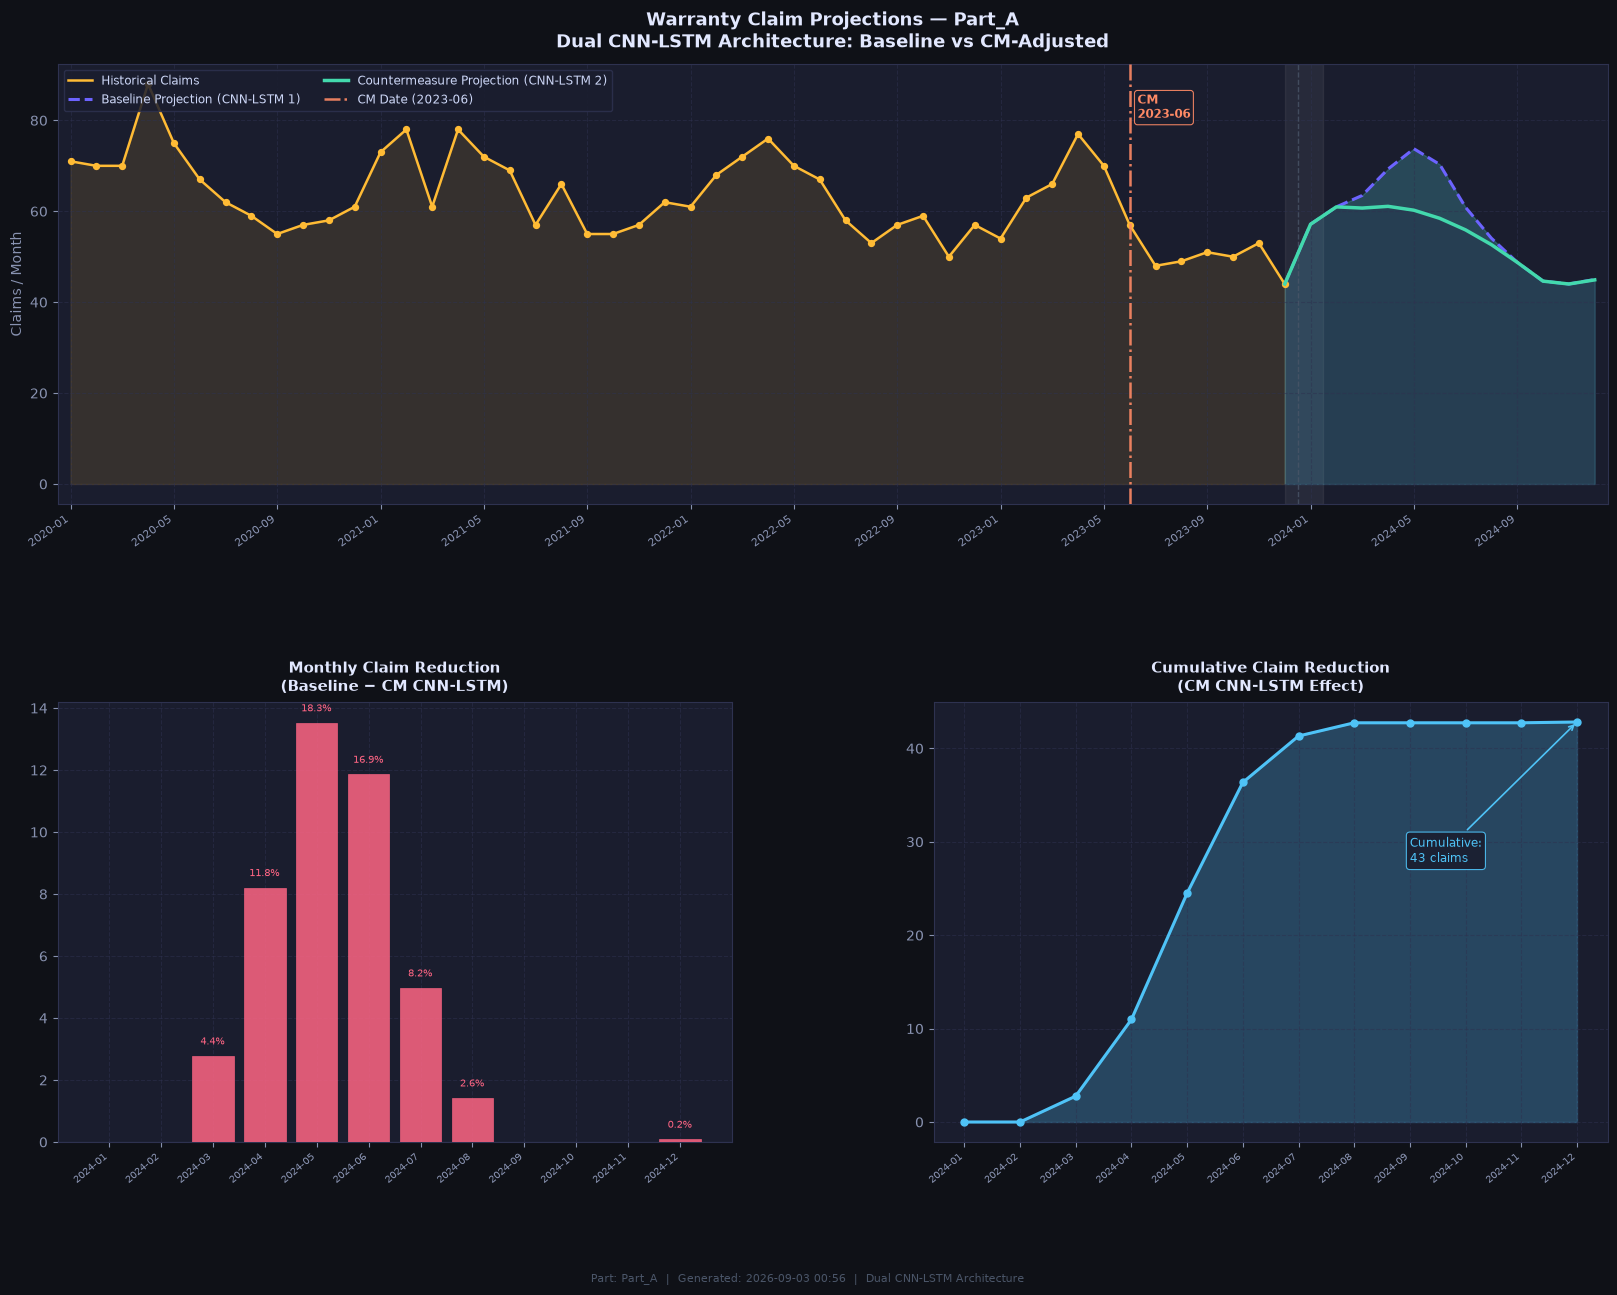

  ✅ Chart saved → .\cnn_lstm_chart_projections.png


In [7]:
# ============================================================
# CELL 7 — Side-by-side visualisation (4-panel)
# ============================================================

def _thin_ticks(labels, max_ticks=14):
    n = len(labels); step = max(1, n // max_ticks)
    idxs = list(range(0, n, step))
    return idxs, [labels[i] for i in idxs]


def plot_projections(hist_periods, hist_claims, future_labels,
                     baseline_forecast, cm_forecast, cm_production,
                     comparison, cm_result, part_name,
                     countermeasure_taken, cm_date, model_name="CNN-LSTM"):
    hist_labels = [str(p) for p in hist_periods]
    all_labels  = hist_labels + future_labels
    n_hist      = len(hist_labels); n_fc = len(future_labels)
    fig = plt.figure(figsize=(20, 14), facecolor="#0F1117")
    from matplotlib.gridspec import GridSpec
    gs  = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.3)
    ax_main = fig.add_subplot(gs[0, :]); ax_bar = fig.add_subplot(gs[1, 0]); ax_cum = fig.add_subplot(gs[1, 1])
    TC = "#E2E8FF"; SC = "#8892B0"

    ax = ax_main
    ax.fill_between(range(n_hist), hist_claims, alpha=0.12, color=C_HIST)
    ax.plot(range(n_hist), hist_claims, color=C_HIST, lw=1.8, zorder=3, label="Historical Claims")
    ax.scatter(range(n_hist), hist_claims, color=C_HIST, s=18, zorder=4)
    ax.axvspan(n_hist - 1, n_hist + 0.5, alpha=0.06, color="white")
    ax.axvline(n_hist - 0.5, color="#4A5568", ls="--", lw=1.0, alpha=0.8)
    fc_x = range(n_hist - 1, n_hist + n_fc)
    fc_y_base = np.concatenate([[hist_claims[-1]], baseline_forecast])
    ax.fill_between(fc_x, fc_y_base, alpha=0.10, color=C_BASELINE)
    ax.plot(fc_x, fc_y_base, color=C_BASELINE, lw=2.2, ls="--", zorder=5,
            label=f"Baseline Projection ({model_name} 1)")
    if countermeasure_taken:
        fc_y_cm = np.concatenate([[hist_claims[-1]], cm_forecast])
        ax.fill_between(fc_x, fc_y_cm, alpha=0.15, color=C_CM)
        ax.plot(fc_x, fc_y_cm, color=C_CM, lw=2.5, zorder=6,
                label=f"Countermeasure Projection ({model_name} 2)")
        ax.fill_between(np.array(list(fc_x)), fc_y_base, fc_y_cm,
                        where=(fc_y_base >= fc_y_cm), alpha=0.20, color=C_CM,
                        interpolate=True, label="_nolegend_")
        if cm_date:
            try:
                cm_p = pd.Period(cm_date, freq="M")
                cm_idx = next((i for i, p in enumerate(hist_periods) if pd.Period(p, freq="M") == cm_p), None)
                if cm_idx is None:
                    cm_idx = next((n_hist + j for j, p in enumerate(future_labels) if pd.Period(p, freq="M") == cm_p), None)
                if cm_idx is not None:
                    ax.axvline(cm_idx, color=C_CM_LINE, lw=1.8, ls="-.", alpha=0.9, zorder=7,
                               label=f"CM Date ({cm_date})")
                    ax.text(cm_idx + 0.3, ax.get_ylim()[1] * 0.93,
                            f"CM\n{cm_date}", color=C_CM_LINE, fontsize=8.5, fontweight="bold",
                            va="top", ha="left",
                            bbox=dict(fc="#1A1D2E", ec=C_CM_LINE, alpha=0.9, boxstyle="round,pad=0.25", lw=0.8))
            except Exception: pass
    ax.set_title(f"Warranty Claim Projections — {part_name}\n"
                 f"Dual {model_name} Architecture: Baseline vs CM-Adjusted",
                 color=TC, fontsize=13, fontweight="bold", pad=12)
    xi, xl = _thin_ticks(all_labels)
    ax.set_xticks(xi); ax.set_xticklabels(xl, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("Claims / Month", color=SC); ax.legend(loc="upper left", fontsize=8.5, ncol=2)
    ax.set_xlim(-0.5, len(all_labels) - 0.5)

    ax = ax_bar
    if countermeasure_taken:
        monthly_red = comparison["monthly_reduction"]; pct_red = comparison["pct_reduction"]
        x = np.arange(n_fc)
        bars = ax.bar(x, monthly_red, color=C_REDUCTION, alpha=0.85, edgecolor="#FF6584", lw=0.5, zorder=3)
        for bar, pct in zip(bars, pct_red):
            if bar.get_height() > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f"{pct:.1f}%",
                        ha="center", va="bottom", fontsize=7, color=C_REDUCTION)
        ax.set_title(f"Monthly Claim Reduction\n(Baseline − CM {model_name})", color=TC, fontsize=11, fontweight="bold", pad=8)
        ax.set_xticks(np.arange(n_fc)); ax.set_xticklabels(future_labels, rotation=40, ha="right", fontsize=7.5)
        ax.axhline(0, color="#4A5568", lw=0.8)
    else:
        ax.text(0.5, 0.5, f"No Countermeasure\n(Baseline Only)", transform=ax.transAxes,
                ha="center", va="center", fontsize=13, color="#4A5568", style="italic")
        ax.set_title("Monthly Reduction", color=TC, fontsize=11, fontweight="bold", pad=8)

    ax = ax_cum
    if countermeasure_taken:
        cum_red = comparison["cumulative_reduction"]; x = np.arange(n_fc)
        ax.fill_between(x, cum_red, alpha=0.25, color=C_CUM)
        ax.plot(x, cum_red, color=C_CUM, lw=2.2, marker="o", markersize=5, zorder=4)
        ax.annotate(f"Cumulative:\n{cum_red[-1]:,.0f} claims",
                    xy=(x[-1], cum_red[-1]), xytext=(max(x[-1]-3,0), cum_red[-1]*0.65),
                    fontsize=8.5, color=C_CUM,
                    arrowprops=dict(arrowstyle="->", color=C_CUM, lw=1.2),
                    bbox=dict(fc="#1A1D2E", ec=C_CUM, alpha=0.9, boxstyle="round,pad=0.3", lw=0.8))
        ax.set_title(f"Cumulative Claim Reduction\n(CM {model_name} Effect)", color=TC, fontsize=11, fontweight="bold", pad=8)
        ax.set_xticks(np.arange(n_fc)); ax.set_xticklabels(future_labels, rotation=40, ha="right", fontsize=7.5)
    else:
        ax.text(0.5, 0.5, "No Countermeasure\n(Baseline Only)", transform=ax.transAxes,
                ha="center", va="center", fontsize=13, color="#4A5568", style="italic")
        ax.set_title("Cumulative Reduction", color=TC, fontsize=11, fontweight="bold", pad=8)

    ts = datetime.now().strftime("%Y-%m-%d %H:%M")
    fig.text(0.5, 0.01, f"Part: {part_name}  |  Generated: {ts}  |  Dual {model_name} Architecture",
             ha="center", fontsize=8, color="#4A5568")
    return fig


fig_main = plot_projections(
    hist_periods=periods, hist_claims=claims_arr, future_labels=future_labels,
    baseline_forecast=baseline_forecast, cm_forecast=cm_forecast,
    cm_production=cm_production, comparison=comparison, cm_result=cm_result,
    part_name=selected_part, countermeasure_taken=COUNTERMEASURE_TAKEN,
    cm_date=COUNTERMEASURE_DATE if COUNTERMEASURE_TAKEN else None, model_name="CNN-LSTM",
)
_chart_main_path = os.path.join(OUTPUT_DIR_NB, "cnn_lstm_chart_projections.png")
fig_main.savefig(_chart_main_path, dpi=180, bbox_inches="tight", facecolor=fig_main.get_facecolor())
plt.show()
print(f"  ✅ Chart saved → {_chart_main_path}")


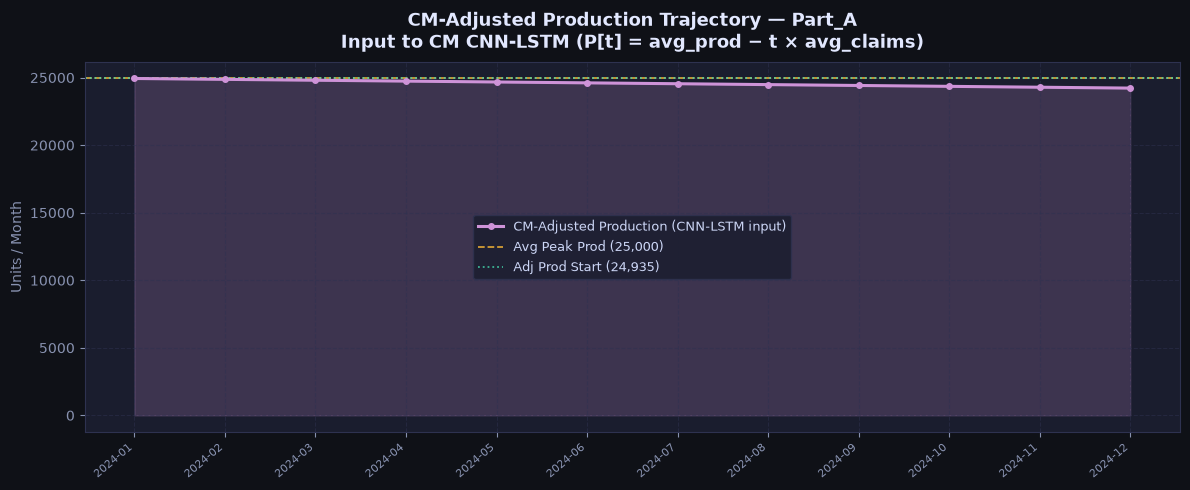

  ✅ Production chart saved → .\cnn_lstm_chart_production.png


In [8]:
# ── Production trajectory chart ───────────────────────────────────────────────

_chart_prod_path = None
if COUNTERMEASURE_TAKEN and cm_result["cm_active"]:
    fig, ax = plt.subplots(figsize=(12, 5), facecolor="#0F1117")
    ax.set_facecolor("#1A1D2E")
    x = np.arange(len(future_labels))
    cm_production = cm_result["cm_production"]
    ax.fill_between(x, cm_production, alpha=0.20, color=C_PROD)
    ax.plot(x, cm_production, color=C_PROD, lw=2.2, marker="o", markersize=4, zorder=4,
            label="CM-Adjusted Production (CNN-LSTM input)")
    ax.axhline(cm_result["avg_peak_prod"], color="#FFBB35", lw=1.3, ls="--", alpha=0.8,
               label=f"Avg Peak Prod ({cm_result['avg_peak_prod']:,.0f})")
    ax.axhline(cm_result["adj_prod"], color="#43D9AD", lw=1.3, ls=":", alpha=0.8,
               label=f"Adj Prod Start ({cm_result['adj_prod']:,.0f})")
    ax.set_title(f"CM-Adjusted Production Trajectory — {selected_part}\n"
                 f"Input to CM CNN-LSTM (P[t] = avg_prod − t × avg_claims)",
                 color="#E2E8FF", fontsize=13, fontweight="bold", pad=10)
    ax.set_ylabel("Units / Month", color="#8892B0")
    ax.set_xticks(x); ax.set_xticklabels(future_labels, rotation=40, ha="right", fontsize=8)
    ax.legend(fontsize=9); ax.grid(True, color="#2E3250", ls="--", alpha=0.5)
    fig.tight_layout()
    _chart_prod_path = os.path.join(OUTPUT_DIR_NB, "cnn_lstm_chart_production.png")
    fig.savefig(_chart_prod_path, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    print(f"  ✅ Production chart saved → {_chart_prod_path}")
else:
    print("  ℹ️  Production chart shown in CM mode only")


In [9]:
# ============================================================
# CELL 8 — Numerical results
# ============================================================
from IPython.display import display, HTML

def _kpi(label, value, unit="", color="#43D9AD"):
    return (f'<div style="display:inline-block;margin:8px;padding:16px 24px;'
            f'background:#1A1D2E;border:1px solid {color};border-radius:10px;'
            f'min-width:160px;text-align:center;">'
            f'<div style="color:#8892B0;font-size:11px;margin-bottom:6px;">{label}</div>'
            f'<div style="color:{color};font-size:22px;font-weight:bold;">{value}</div>'
            f'<div style="color:#4A5568;font-size:10px;">{unit}</div></div>')

kpi_html  = f'<div style="font-family:DejaVu Sans,sans-serif;"><h3 style="color:#CCD6F6;">📊 CNN-LSTM Results — {selected_part}</h3>'
kpi_html += _kpi("Baseline Total", f"{baseline_forecast.sum():,.0f}", "claims", "#6C63FF")
if COUNTERMEASURE_TAKEN:
    kpi_html += _kpi("CM Total",     f"{cm_forecast.sum():,.0f}",                     "claims",      "#43D9AD")
    kpi_html += _kpi("Claims Saved", f"{comparison['total_reduction']:,.0f}",        "claims",      "#FF6584")
    kpi_html += _kpi("Reduction",    f"{comparison['total_pct_reduction']:.1f}%",    "of baseline", "#FFBB35")
    if comparison["total_cost_savings"]:
        kpi_html += _kpi("Cost Savings", f"${comparison['total_cost_savings']:,.0f}", "estimated", "#4FC3F7")
kpi_html += "</div>"
display(HTML(kpi_html))

print("\nMonth-by-Month Comparison")
comp_df = comparison["comparison_df"].copy()
for col in ["Baseline_Claims","CM_Claims","Monthly_Reduction","Cumulative_Reduction"]:
    comp_df[col] = comp_df[col].round(1)
comp_df["Reduction_%"] = comp_df["Reduction_%"].round(2)
if "Cost_Savings" in comp_df.columns: comp_df["Cost_Savings"] = comp_df["Cost_Savings"].round(0)
display(comp_df)
_tbl = os.path.join(OUTPUT_DIR_NB, "cnn_lstm_comparison.csv")
comp_df.to_csv(_tbl, index=False)
print(f"  ✅ CSV saved → {_tbl}")



Month-by-Month Comparison


,Month,Baseline_Claims,CM_Claims,Monthly_Reduction,Cumulative_Reduction,Reduction_%,Cost_Savings
0,2024-01,57.1,57.1,0.0,0.0,0.00,0.0
1,2024-02,61.0,61.0,0.0,0.0,0.00,0.0
2,2024-03,63.5,60.7,2.8,2.8,4.37,2357.0
3,2024-04,69.3,61.1,8.2,11.0,11.84,6973.0
4,2024-05,73.8,60.2,13.5,24.5,18.33,11492.0
5,2024-06,70.3,58.5,11.9,36.4,16.87,10080.0
6,2024-07,60.9,55.9,5.0,41.3,8.16,4222.0
7,2024-08,54.1,52.7,1.4,42.7,2.62,1204.0
8,2024-09,48.8,48.8,0.0,42.7,0.00,0.0
9,2024-10,44.6,44.6,0.0,42.7,0.00,0.0


  ✅ CSV saved → .\cnn_lstm_comparison.csv


In [10]:
# ============================================================
# CELL 9 — PowerPoint export
# ============================================================

def build_pptx_report(part_name, baseline_forecast, cm_forecast,
                       comparison, cm_result, future_labels, hist_claims,
                       chart_main_path, chart_prod_path,
                       countermeasure_taken, cm_date, output_path, model_name="CNN-LSTM"):
    try:
        from pptx import Presentation
        from pptx.util import Inches, Pt
        from pptx.dml.color import RGBColor
        from pptx.enum.text import PP_ALIGN
    except ImportError:
        print("  ⚠️  python-pptx not installed: pip install python-pptx"); return ""
    BG=RGBColor(0x0F,0x11,0x17); BG2=RGBColor(0x1A,0x1D,0x2E); WHITE=RGBColor(0xCC,0xD6,0xF6)
    GREY=RGBColor(0x88,0x92,0xB0); TEAL=RGBColor(0x43,0xD9,0xAD); PURP=RGBColor(0x6C,0x63,0xFF)
    ROSE=RGBColor(0xFF,0x65,0x84); AMBER=RGBColor(0xFF,0xBB,0x35); SKY=RGBColor(0x4F,0xC3,0xF7)
    def _bg(slide, c=BG): f=slide.background.fill; f.solid(); f.fore_color.rgb=c
    def _txt(slide, text, l, t, w, h, sz=18, bold=False, color=WHITE, align=PP_ALIGN.LEFT, italic=False):
        tb=slide.shapes.add_textbox(l,t,w,h); tf=tb.text_frame; tf.word_wrap=True
        p=tf.paragraphs[0]; p.alignment=align; r=p.add_run(); r.text=str(text)
        r.font.size=Pt(sz); r.font.bold=bold; r.font.italic=italic; r.font.color.rgb=color
    def _rect(slide, l, t, w, h, rgb):
        s=slide.shapes.add_shape(1,l,t,w,h); s.fill.solid(); s.fill.fore_color.rgb=rgb; s.line.fill.background()
    prs=Presentation(); prs.slide_width=Inches(13.33); prs.slide_height=Inches(7.5)
    blank=prs.slide_layouts[6]; ts=datetime.now().strftime("%Y-%m-%d %H:%M")
    accent=TEAL if countermeasure_taken else PURP
    # Slide 1
    s1=prs.slides.add_slide(blank); _bg(s1)
    _rect(s1,Inches(0),Inches(3.2),Inches(13.33),Inches(0.06),accent)
    _txt(s1,f"{model_name} Projection Report — Dual Architecture",Inches(1),Inches(1.5),Inches(11),Inches(1),sz=26,bold=True,color=WHITE,align=PP_ALIGN.CENTER)
    _txt(s1,f"Part: {part_name}",Inches(1),Inches(2.6),Inches(11),Inches(0.6),sz=18,color=accent,align=PP_ALIGN.CENTER)
    mode=f"Baseline+CM {model_name}  |  CM Date: {cm_date}" if countermeasure_taken else f"Baseline {model_name} Only"
    _txt(s1,mode,Inches(1),Inches(3.4),Inches(11),Inches(0.5),sz=13,color=GREY,align=PP_ALIGN.CENTER)
    _txt(s1,f"Generated: {ts}",Inches(1),Inches(6.8),Inches(11),Inches(0.4),sz=9,color=GREY,align=PP_ALIGN.CENTER,italic=True)
    # Slide 2 — KPIs
    s2=prs.slides.add_slide(blank); _bg(s2)
    _txt(s2,"Executive Summary",Inches(0.5),Inches(0.3),Inches(12),Inches(0.6),sz=22,bold=True,color=WHITE)
    kpis=[("Forecast Horizon",f"{len(future_labels)} months",PURP),("Historical",f"{len(hist_claims)} months",AMBER),
          ("Baseline Total",f"{baseline_forecast.sum():,.0f} claims",PURP)]
    if countermeasure_taken:
        kpis+=[(f"CM Total",f"{cm_forecast.sum():,.0f} claims",TEAL),
               ("Claims Saved",f"{comparison['total_reduction']:,.0f}",ROSE),
               ("Reduction %",f"{comparison['total_pct_reduction']:.1f}%",AMBER)]
        if comparison["total_cost_savings"]: kpis.append(("Est. Savings",f"${comparison['total_cost_savings']:,.0f}",SKY))
    for idx,(lbl,val,col) in enumerate(kpis):
        r,c=divmod(idx,4); bx=Inches(0.4+c*3.2); by=Inches(1.2+r*1.9)
        _rect(s2,bx,by,Inches(3.0),Inches(1.6),BG2); _rect(s2,bx,by,Inches(3.0),Inches(0.05),col)
        _txt(s2,lbl,bx+Inches(0.1),by+Inches(0.15),Inches(2.8),Inches(0.35),sz=9,color=GREY)
        _txt(s2,val,bx+Inches(0.1),by+Inches(0.6),Inches(2.8),Inches(0.7),sz=18,bold=True,color=col)
    # Slide 3 — Chart
    s3=prs.slides.add_slide(blank); _bg(s3)
    _txt(s3,f"Projection Chart — Baseline vs CM {model_name}",Inches(0.3),Inches(0.15),Inches(12.5),Inches(0.5),sz=16,bold=True,color=WHITE)
    if os.path.exists(chart_main_path): s3.shapes.add_picture(chart_main_path,Inches(0.25),Inches(0.7),Inches(12.8),Inches(6.6))
    # Slide 4 — Production
    if countermeasure_taken and chart_prod_path and os.path.exists(chart_prod_path):
        s4=prs.slides.add_slide(blank); _bg(s4)
        _txt(s4,f"CM-Adjusted Production (Input to CM {model_name})",Inches(0.3),Inches(0.15),Inches(12.5),Inches(0.5),sz=16,bold=True,color=WHITE)
        s4.shapes.add_picture(chart_prod_path,Inches(0.4),Inches(0.75),Inches(12.5),Inches(6.2))
    # Slide 5 — Table
    s5=prs.slides.add_slide(blank); _bg(s5)
    _txt(s5,"Month-by-Month Comparison",Inches(0.3),Inches(0.15),Inches(12.5),Inches(0.5),sz=16,bold=True,color=WHITE)
    comp_df=comparison["comparison_df"]; cols=list(comp_df.columns); n_rows=len(comp_df)
    tbl=s5.shapes.add_table(n_rows+1,len(cols),Inches(0.2),Inches(0.75),Inches(12.9),Inches(min(6.5,0.38*(n_rows+1)))).table
    for c,col in enumerate(cols):
        cell=tbl.cell(0,c); cell.text=col; cell.fill.solid(); cell.fill.fore_color.rgb=RGBColor(0x12,0x14,0x22)
        p=cell.text_frame.paragraphs[0]; p.runs[0].font.size=Pt(8); p.runs[0].font.bold=True; p.runs[0].font.color.rgb=TEAL
    for r,(_, row_data) in enumerate(comp_df.iterrows(), start=1):
        for c,col in enumerate(cols):
            cell=tbl.cell(r,c); val=row_data[col]
            cell.text=f"{val:.1f}" if isinstance(val,float) else str(val)
            cell.fill.solid(); cell.fill.fore_color.rgb=BG2 if r%2==0 else BG
            p=cell.text_frame.paragraphs[0]; p.runs[0].font.size=Pt(7.5); p.runs[0].font.color.rgb=WHITE
    prs.save(output_path); return output_path


if EXPORT_PPT:
    _ppt_fname = f"cnn_lstm_{selected_part.replace(' '  ,'_')}_{datetime.now().strftime('%Y%m%d_%H%M')}.pptx"
    _ppt_path  = os.path.join(OUTPUT_DIR_NB, _ppt_fname)
    result     = build_pptx_report(
        part_name=selected_part, baseline_forecast=baseline_forecast, cm_forecast=cm_forecast,
        comparison=comparison, cm_result=cm_result, future_labels=future_labels,
        hist_claims=claims_arr, chart_main_path=_chart_main_path, chart_prod_path=_chart_prod_path,
        countermeasure_taken=COUNTERMEASURE_TAKEN,
        cm_date=COUNTERMEASURE_DATE if COUNTERMEASURE_TAKEN else None,
        output_path=_ppt_path, model_name="CNN-LSTM",
    )
    if result: print(f"\n✅ PPT saved → {os.path.abspath(result)}")
    else:      print("  ⚠️  PPT export skipped")
else:
    print("  ℹ️  EXPORT_PPT = True to enable")

print()
print("=" * 60)
print("  CNN-LSTM NOTEBOOK COMPLETE")
print("=" * 60)
print(f"  Part         : {selected_part}")
print(f"  CM Active    : {cm_result['cm_active']}")
print(f"  Baseline Sum : {baseline_forecast.sum():,.0f} claims  (CNN-LSTM 1)")
if cm_result["cm_active"]:
    print(f"  CM Sum       : {cm_forecast.sum():,.0f} claims  (CNN-LSTM 2)")
    print(f"  Reduction    : {comparison['total_reduction']:,.0f} claims ({comparison['total_pct_reduction']:.1f}%)")
print("=" * 60)



✅ PPT saved → d:\forecasting_cursor_copy2\cnn_lstm_Part_A_20260903_0056.pptx

  CNN-LSTM NOTEBOOK COMPLETE
  Part         : Part_A
  CM Active    : True
  Baseline Sum : 692 claims  (CNN-LSTM 1)
  CM Sum       : 649 claims  (CNN-LSTM 2)
  Reduction    : 43 claims (6.2%)


In [ ]:
# ============================================================
# CELL 10 — Edge Case Testing
# ============================================================

def quick_test_cnn_lstm(n_months=36, horizon=12, epochs=15, seed=42):
    """Smoke test: fit BOTH CNN-LSTM models on sine+noise series."""
    np.random.seed(seed)
    t = np.arange(n_months)
    claims = np.clip(50 + 15*np.sin(2*np.pi*t/12) + np.random.normal(0, 4, n_months), 1, None)
    periods_t = [str(pd.Period("2021-01", freq="M") + i) for i in range(n_months)]
    prod_t    = np.full(n_months, 25_000.0)

    feat_df = build_univariate_features(claims, periods_t, production=prod_t)
    feats_t = feat_df[UNI_FEATURE_COLS].to_numpy(dtype=float)
    csc_t = MinMaxScaler(); esc_t = MinMaxScaler()
    ys_t  = csc_t.fit_transform(claims[:, None]).ravel()
    es_t  = esc_t.fit_transform(feats_t)
    W_t   = min(12, max(4, n_months // 3))
    H_t   = min(horizon, max(1, n_months - W_t - 1))
    X_t, Y_t = build_window_dataset(ys_t, es_t, W_t, H_t)
    if X_t is None: print("  Insufficient windows"); return

    last_win = np.concatenate([ys_t[-W_t:, None], es_t[-W_t:]], axis=1)[None]

    print(f"  [Baseline CNN-LSTM] fitting on {n_months}-month series ...")
    m1 = CNNLSTMForecaster(lookback=W_t, n_features=X_t.shape[-1], horizon=H_t,
                            epochs=epochs, seed=seed, early_patience=5)
    m1.fit(X_t, Y_t)
    fc1 = np.clip(csc_t.inverse_transform(np.clip(m1.predict(last_win)[0],0,1).reshape(-1,1)).ravel(), 0, None)

    avg_pc = claims.mean(); adj_p = max(prod_t.mean() - avg_pc, 1.0)
    cm_hp  = build_cm_adjusted_production(adj_p, avg_pc, n_months, WARRANTY_MONTHS)
    feats_cm = feats_t.copy(); feats_cm[:, UNI_FEATURE_COLS.index("Production_Vol")] = cm_hp
    esc_cm = MinMaxScaler(); es_cm = esc_cm.fit_transform(feats_cm)
    X_cm, Y_cm = build_window_dataset(ys_t, es_cm, W_t, H_t)
    last_win_cm = np.concatenate([ys_t[-W_t:, None], es_cm[-W_t:]], axis=1)[None]

    # Warranty-expiry physics
    rw = np.maximum(0.0, 1.0 - np.arange(H_t, dtype=float) / float(WARRANTY_MONTHS))
    cm_physics = avg_pc * rw

    print(f"  [CM CNN-LSTM]       fitting on {n_months}-month series ...")
    m2 = CNNLSTMForecaster(lookback=W_t, n_features=X_cm.shape[-1], horizon=H_t,
                            epochs=epochs, seed=seed+1, early_patience=5, dropout=0.15)
    m2.fit(X_cm, Y_cm)
    fc2_raw = np.clip(csc_t.inverse_transform(np.clip(m2.predict(last_win_cm)[0],0,1).reshape(-1,1)).ravel(), 0, None)
    fc2 = np.clip(0.70 * cm_physics + 0.30 * np.minimum(fc2_raw, fc1), 0.0, fc1)

    print()
    print(f"  Baseline  : {np.round(fc1, 1)}")
    print(f"  CM        : {np.round(fc2, 1)}")
    print(f"  Reduction : {np.round(fc1 - fc2, 1)}")
    print(f"  CM ≤ Baseline everywhere: {bool(np.all(fc2 <= fc1 + 1e-6))}")
    return fc1, fc2


print("=" * 55)
print("  CNN-LSTM EDGE CASE TESTS")
print("=" * 55)
_ = quick_test_cnn_lstm(n_months=36, horizon=12, epochs=15)
print()
_ = quick_test_cnn_lstm(n_months=48, horizon=12, epochs=15)
print()
print("✅ Edge case tests complete")


  CNN-LSTM EDGE CASE TESTS
  [Baseline CNN-LSTM] fitting on 36-month series ...


CNN-LSTM epochs: 100%|██████████| 15/15 [00:45<00:00,  3.04s/ep, loss=0.0309]


  [CM CNN-LSTM]       fitting on 36-month series ...


CNN-LSTM epochs: 100%|██████████| 15/15 [00:45<00:00,  3.06s/ep, loss=0.0371]



  Baseline  : [46.6 58.2 65.2 71.1 71.1 71.1 59.  50.7 42.6 33.9 34.4 40.1]
  CM        : [46.6 47.7 46.9 46.8 46.5 46.4 46.1 43.  39.6 33.9 34.4 36. ]
  Reduction : [ 0.  10.5 18.3 24.2 24.6 24.7 12.9  7.7  3.   0.   0.   4.1]
  CM ≤ Baseline everywhere: True

  [Baseline CNN-LSTM] fitting on 48-month series ...


CNN-LSTM epochs: 100%|██████████| 15/15 [01:28<00:00,  5.91s/ep, loss=0.0289]


  [CM CNN-LSTM]       fitting on 48-month series ...


CNN-LSTM epochs:  20%|██        | 3/15 [00:19<01:16,  6.39s/ep, loss=0.0742]